# GUS01C: GeoTERYT Database

This notebook demonstrates the GeoTERYT database system for Polish administrative divisions.

## Overview
- Build database from harmonized TERYT data (from GUS01A)
- Load geometries from shapefiles (from GUS01B)
- Search and query functionality
- Geometry operations (merging, best geometry selection)
- Overlay operations (pre-1999 voivodeships)

In [1]:
import os
import sys
import pandas as pd
from pathlib import Path
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import importlib

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
            return p
    return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geospatial_root = repo_root.parent.parent / 'Data' / 'Geospatial'
geometry_root = repo_root.parent.parent / 'Data' / 'Geospatial' / 'geometry'
gus_root = Path(os.getcwd()).parent.parent.parent.parent / "Data" / "GUS"

os.chdir(repo_root)
if str(repo_root / 'Code' / 'tools') not in sys.path:
    sys.path.append(str(repo_root / 'Code' / 'tools'))

# Import local toolkit (with reload for development)
import local_utility_functions as luf
import geoTERYT_db as gtdb
importlib.reload(gtdb)

print(f"Repo root: {repo_root}")
print(f"GUS root: {gus_root}")
print(f"Geometry root: {geometry_root}")
print(f"geoTERYT_db version: {gtdb.__doc__.split(chr(10))[0] if gtdb.__doc__ else 'unknown'}")

Repo root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper
GUS root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/GUS
Geometry root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geometry
geoTERYT_db version: 


## 1. Load Harmonized TERYT Data

Load the mega DataFrame created in GUS01A notebook.

In [2]:
# Load the saved mega_df from GUS01A/GUS01B
mega_df = pd.read_csv(geospatial_root / "teryt_df.csv", encoding="utf-8")

# Ensure proper formatting
v_tostring = np.vectorize(lambda x: str(x))
v_zero_pad = np.vectorize(lambda x, n: str(x).zfill(n))
mega_df['id'] = v_zero_pad(v_tostring(mega_df['id']), 7)

print(f"Loaded mega_df: {len(mega_df)} rows")
print(f"Years: {mega_df['year'].min()} - {mega_df['year'].max()}")
print(f"Columns: {list(mega_df.columns)}")
mega_df.head()

Loaded mega_df: 107346 rows
Years: 1999 - 2024
Columns: ['year', 'WOJ', 'POW', 'GMI', 'RODZ', 'id', 'NAZWA', 'NAZWA_DOD', 'level', 'kind', 'STAN_NA', 'if_changed', 'when_changed', 'notes', 'teryt', 'geometry_available', 'geometry_years']


,year,WOJ,POW,GMI,RODZ,id,NAZWA,NAZWA_DOD,level,kind,STAN_NA,if_changed,when_changed,notes,teryt,geometry_available,geometry_years
0,1999,2,0,0,0,0200000,DOLNOŚLĄSKIE,województwo,2,NaN,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}",200000,False,NaN
1,1999,2,1,0,0,0201000,bolesławiecki,powiat,5,NaN,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}",201000,False,NaN
2,1999,2,1,1,1,0201011,Bolesławiec,gmina miejska,6,urban,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}",201011,True,2015 2016 2017 2018 2021 2022 2023
3,1999,2,1,2,2,0201022,Bolesławiec,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}",201022,True,2015 2016 2017 2018 2021 2022 2023
4,1999,2,1,3,2,0201032,Gromadka,gmina wiejska,6,rural,1999-01-01,False,NaN,"{'number_of_changes': 0, 'changes': []}",201032,True,2015 2016 2017 2018 2021 2022 2023


## 2. Load Geometry Files

In [3]:
import re

# Scan for geometry files
geometry_files = [f for f in os.listdir(geometry_root) if not f.startswith('.')]
geometry_paths = [geometry_root / f for f in geometry_files]

shape_files = []
for i in range(len(geometry_paths)):
    if geometry_paths[i].is_dir():
        dir_contents = os.listdir(geometry_paths[i])
        for file in dir_contents:
            if file.endswith('.shp'):
                shape_files.append(geometry_paths[i] / file)

shape_files.sort()
# Filter to gmina-level files
shape_files = [f for f in shape_files if 'Obszary' in f.name or 'gmin' in f.name]

print("Found shapefiles:")
for f in shape_files:
    print(f"  {f.parent.name}/{f.name}")

Found shapefiles:
  PRG_jednostki_administracyjne_2005/Obszary.shp
  PRG_jednostki_administracyjne_2006/Obszary.shp
  PRG_jednostki_administracyjne_2007/Obszary.shp
  PRG_jednostki_administracyjne_2008/Obszary.shp
  PRG_jednostki_administracyjne_2009/Obszary.shp
  PRG_jednostki_administracyjne_2010/Obszary.shp
  PRG_jednostki_administracyjne_2011/Obszary.shp
  PRG_jednostki_administracyjne_2012/Obszary_1992_region.shp
  PRG_jednostki_administracyjne_2015/gminy.shp
  PRG_jednostki_administracyjne_2016/gminy.shp
  PRG_jednostki_administracyjne_2017/gminy.shp
  PRG_jednostki_administracyjne_2018/gminy.shp
  PRG_jednostki_administracyjne_2021/A03_Granice_gmin.shp
  PRG_jednostki_administracyjne_2022/A03_Granice_gmin.shp
  PRG_jednostki_administracyjne_2023/A03_Granice_gmin.shp


In [4]:
# Load all shapefiles into a dictionary
gdf_list = {}
for file in shape_files:
    key = str(file.parent)[-4:] + "_" + str(file.stem)
    try:
        gdf = gpd.read_file(file)
        gdf_list[key] = gdf
        print(f"Loaded {key}: {len(gdf)} features")
    except Exception as e:
        print(f"Error loading {key}: {e}")

print(f"\nTotal loaded: {len(gdf_list)} GeoDataFrames")

Loaded 2005_Obszary: 3175 features
Loaded 2006_Obszary: 3183 features
Loaded 2007_Obszary: 3183 features
Loaded 2008_Obszary: 3185 features
Loaded 2009_Obszary: 3190 features
Loaded 2010_Obszary: 3203 features
Loaded 2011_Obszary: 3209 features
Loaded 2012_Obszary_1992_region: 3209 features
Loaded 2015_gminy: 2481 features
Loaded 2016_gminy: 2481 features
Loaded 2017_gminy: 2478 features
Loaded 2018_gminy: 2478 features
Loaded 2021_A03_Granice_gmin: 2477 features
Loaded 2022_A03_Granice_gmin: 2477 features
Loaded 2023_A03_Granice_gmin: 2477 features

Total loaded: 15 GeoDataFrames


In [5]:
# Prepare GeoDataFrames: standardize teryt column and CRS
for key in gdf_list:
    print(f"Processing {key}...")
    
    # Extract year from key
    match = re.search(r'\d{4}', key)
    if not match:
        continue
    year = int(match.group(0))
    
    # Standardize column names to lowercase
    gdf_list[key].columns = [col.lower() for col in gdf_list[key].columns]
    
    # Convert CRS to EPSG:2180
    if gdf_list[key].crs is None:
        gdf_list[key] = gdf_list[key].set_crs('EPSG:2180')
    else:
        gdf_list[key] = gdf_list[key].to_crs('EPSG:2180')
    
    # Standardize TERYT column
    if year > 2012:
        gdf_list[key]['teryt'] = gdf_list[key]['jpt_kod_je']
    else:
        # Older files use 'obszar' with NUTS-like codes
        v_NCtT = np.vectorize(luf.nuts_code_to_teryt)
        v_tostring = np.vectorize(lambda x: str(x))
        gdf_list[key]['teryt'] = v_NCtT(v_tostring(gdf_list[key]['obszar'].values))
    
    # Sort by teryt
    gdf_list[key] = gdf_list[key].sort_values(by='teryt').reset_index(drop=True)
    
print("\nAll GeoDataFrames processed!")

Processing 2005_Obszary...
Processing 2006_Obszary...
Processing 2007_Obszary...
Processing 2008_Obszary...
Processing 2009_Obszary...
Processing 2010_Obszary...
Processing 2011_Obszary...
Processing 2012_Obszary_1992_region...
Processing 2015_gminy...
Processing 2016_gminy...
Processing 2017_gminy...
Processing 2018_gminy...
Processing 2021_A03_Granice_gmin...
Processing 2022_A03_Granice_gmin...
Processing 2023_A03_Granice_gmin...

All GeoDataFrames processed!


In [6]:
# For older geometries (<=2012), dissolve sub-units (RODZ 4,5) into main gmina
for key in gdf_list:
    match = re.search(r'\d{4}', key)
    if not match:
        continue
    year = int(match.group(0))
    
    if year <= 2012:
        print(f"Dissolving sub-units for {key}...")
        
        # Fix invalid geometries
        invalid_mask = ~gdf_list[key].is_valid
        if invalid_mask.any():
            print(f"  Fixing {invalid_mask.sum()} invalid geometries...")
            gdf_list[key].loc[invalid_mask, 'geometry'] = gdf_list[key].loc[invalid_mask, 'geometry'].buffer(0)
        
        # Create short teryt (replace last digit with '0')
        gdf_list[key]['teryt_short'] = gdf_list[key]['teryt'].str[:-1] + '0'
        gdf_list[key] = gdf_list[key].dissolve(by='teryt_short', as_index=False)
        gdf_list[key]['teryt'] = gdf_list[key]['teryt_short']
        gdf_list[key] = gdf_list[key].drop(columns=['teryt_short'])
        gdf_list[key] = gdf_list[key].sort_values(by='teryt').reset_index(drop=True)
        
        print(f"  Result: {len(gdf_list[key])} features")

print("\nDissolution complete!")

Dissolving sub-units for 2005_Obszary...
  Fixing 7 invalid geometries...
  Result: 2326 features
Dissolving sub-units for 2006_Obszary...
  Fixing 8 invalid geometries...
  Result: 2327 features
Dissolving sub-units for 2007_Obszary...
  Fixing 7 invalid geometries...
  Result: 2330 features
Dissolving sub-units for 2008_Obszary...
  Fixing 9 invalid geometries...
  Result: 2333 features
Dissolving sub-units for 2009_Obszary...
  Fixing 7 invalid geometries...
  Result: 2339 features
Dissolving sub-units for 2010_Obszary...
  Fixing 6 invalid geometries...
  Result: 2344 features
Dissolving sub-units for 2011_Obszary...
  Fixing 6 invalid geometries...
  Result: 2350 features
Dissolving sub-units for 2012_Obszary_1992_region...
  Fixing 9 invalid geometries...
  Result: 2350 features

Dissolution complete!


## 3. Build the GeoTERYT Database

In [7]:
# Create and build the database
db = gtdb.GeoTERYTDatabase()
db.build_from_harmonized(mega_df, verbose=True)

Building GeoTERYT database v2.0 from harmonized data...
  Pass 1: Collecting unit states by year...
    Found 4560 unique TERYT IDs across all years
  Pass 2: Building records with change detection...
    Name changes detected: 33
    Kind changes detected: 0
    Level changes detected: 0
    Changes from notes: 1606
  Pass 3: Building indices...

✓ Database built successfully!
  Total records: 4,560
  Year range: 1999 - 2024
  Voivodeships: 16
  Powiats: 382
  Gminas: 4162
  Units with changes: 773
  Units with level changes: 0
  Units with kind changes: 0


In [8]:
# Load geometries
db.load_geometries(gdf_list, teryt_column='teryt', verbose=True)

Loading geometries into database (v3.0)...
  Processing 2005_Obszary (year 2005)...
    Linked 34 geometries
  Processing 2006_Obszary (year 2006)...
    Linked 36 geometries
  Processing 2007_Obszary (year 2007)...
    Linked 36 geometries
  Processing 2008_Obszary (year 2008)...
    Linked 36 geometries
  Processing 2009_Obszary (year 2009)...
    Linked 36 geometries
  Processing 2010_Obszary (year 2010)...
    Linked 36 geometries
  Processing 2011_Obszary (year 2011)...
    Linked 36 geometries
  Processing 2012_Obszary_1992_region (year 2012)...
    Linked 36 geometries
  Processing 2015_gminy (year 2015)...
    Linked 2478 geometries
  Processing 2016_gminy (year 2016)...
    Linked 2478 geometries
  Processing 2017_gminy (year 2017)...
    Linked 2478 geometries
  Processing 2018_gminy (year 2018)...
    Linked 2478 geometries
  Processing 2021_A03_Granice_gmin (year 2021)...
    Linked 2477 geometries
  Processing 2022_A03_Granice_gmin (year 2022)...
    Linked 2477 geometries

In [9]:
# Print database summary
db.print_summary()

GeoTERYT Database Summary (v3.0)
Total records:           4,560
Year range:              1999 - 2024
------------------------------------------------------------
Administrative levels:
  Voivodeships (2):      16
  Powiats (5):           382
  Gminas (6):            4162
------------------------------------------------------------
Change tracking:
  Records with changes:      773
  Records with level changes: 0
  Records with kind changes:  0
------------------------------------------------------------
Geometry:
  Records with geometry: 2555
  Geometry years:        [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  Poland boundary set:   False


In [31]:
df = gtdb.as_df(db.get_divisions_by_year(2017, 6))
df

,teryt_id,name,name_dod,level,kind,woj,pow,gmi,rodz,years_valid,...,past_kinds,all_teryt_ids,all_names,changes,has_changes,n_changes,has_geometry,geometry_year,old_woj,old_woj_id
0,1426032,Kotuń,gmina wiejska,6,rural,14,26,03,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[1426032],[Kotuń],[],False,0,True,2023.0,None,None
1,1006022,Andrespol,gmina wiejska,6,rural,10,06,02,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[1006022],[Andrespol],[],False,0,True,2023.0,None,None
2,2801043,Bisztynek,gmina miejsko-wiejska,6,urban-rural,28,01,04,3,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[2801043],[Bisztynek],[],False,0,True,2023.0,None,None
3,2006011,Kolno,gmina miejska,6,urban,20,06,01,1,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[2006011],[Kolno],[],False,0,True,2023.0,None,None
4,0413043,Więcbork,gmina miejsko-wiejska,6,urban-rural,04,13,04,3,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[0413043],[Więcbork],[],False,0,True,2023.0,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2510,2014022,Kołaki Kościelne,gmina wiejska,6,rural,20,14,02,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[2014022],[Kołaki Kościelne],[],False,0,True,2023.0,None,None
2511,2612082,Szydłów,gmina wiejska,6,rural,26,12,08,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[2612082],[Szydłów],"[{'year': 1999, 'type': 'reform', 'description...",True,2,True,2018.0,None,None
2512,0601122,Rokitno,gmina wiejska,6,rural,06,01,12,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[0601122],[Rokitno],[],False,0,True,2023.0,None,None
2513,1414043,Nasielsk,gmina miejsko-wiejska,6,urban-rural,14,14,04,3,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[1414043],[Nasielsk],[],False,0,True,2023.0,None,None


## 5. Geometry Operations

In [ ]:
# Convert to GeoDataFrame for a specific year
gdf_2020 = db.to_geodataframe(year=2017, level=6, exclude_subdivisions=True)

print(f"GeoDataFrame for 2020 gminas: {len(gdf_2020)} rows")
print(f"Columns: {list(gdf_2020.columns)}")
print(f"Rows with geometry: {gdf_2020.geometry.notna().sum()}")

gdf_2020.head()

GeoDataFrame for 2020 gminas: 2515 rows
Columns: ['teryt_id', 'name', 'level', 'kind', 'woj', 'pow', 'gmi', 'rodz', 'name_dod', 'first_year', 'last_year', 'has_geometry', 'geometry_year', 'n_changes', 'has_changes', 'past_names', 'past_teryt_ids', 'past_levels', 'past_kinds', 'geometry']
Rows with geometry: 2483


,teryt_id,name,level,kind,woj,pow,gmi,rodz,name_dod,first_year,last_year,has_geometry,geometry_year,n_changes,has_changes,past_names,past_teryt_ids,past_levels,past_kinds,geometry
0,1426032,Kotuń,6,rural,14,26,03,2,gmina wiejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((703908.737 473569.061, 703902.493 47..."
1,1006022,Andrespol,6,rural,10,06,02,2,gmina wiejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((546256.299 427543.96, 546041.335 427..."
2,2801043,Bisztynek,6,urban-rural,28,01,04,3,gmina miejsko-wiejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((620771.794 685840.81, 620706.424 685..."
3,2006011,Kolno,6,urban,20,06,01,1,gmina miejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((694762.104 615245.56, 694666.718 615..."
4,0413043,Więcbork,6,urban-rural,04,13,04,3,gmina miejsko-wiejska,1999,2024,True,2023.0,0,False,None,None,None,None,"POLYGON ((385170.687 615225.399, 385284.987 61..."


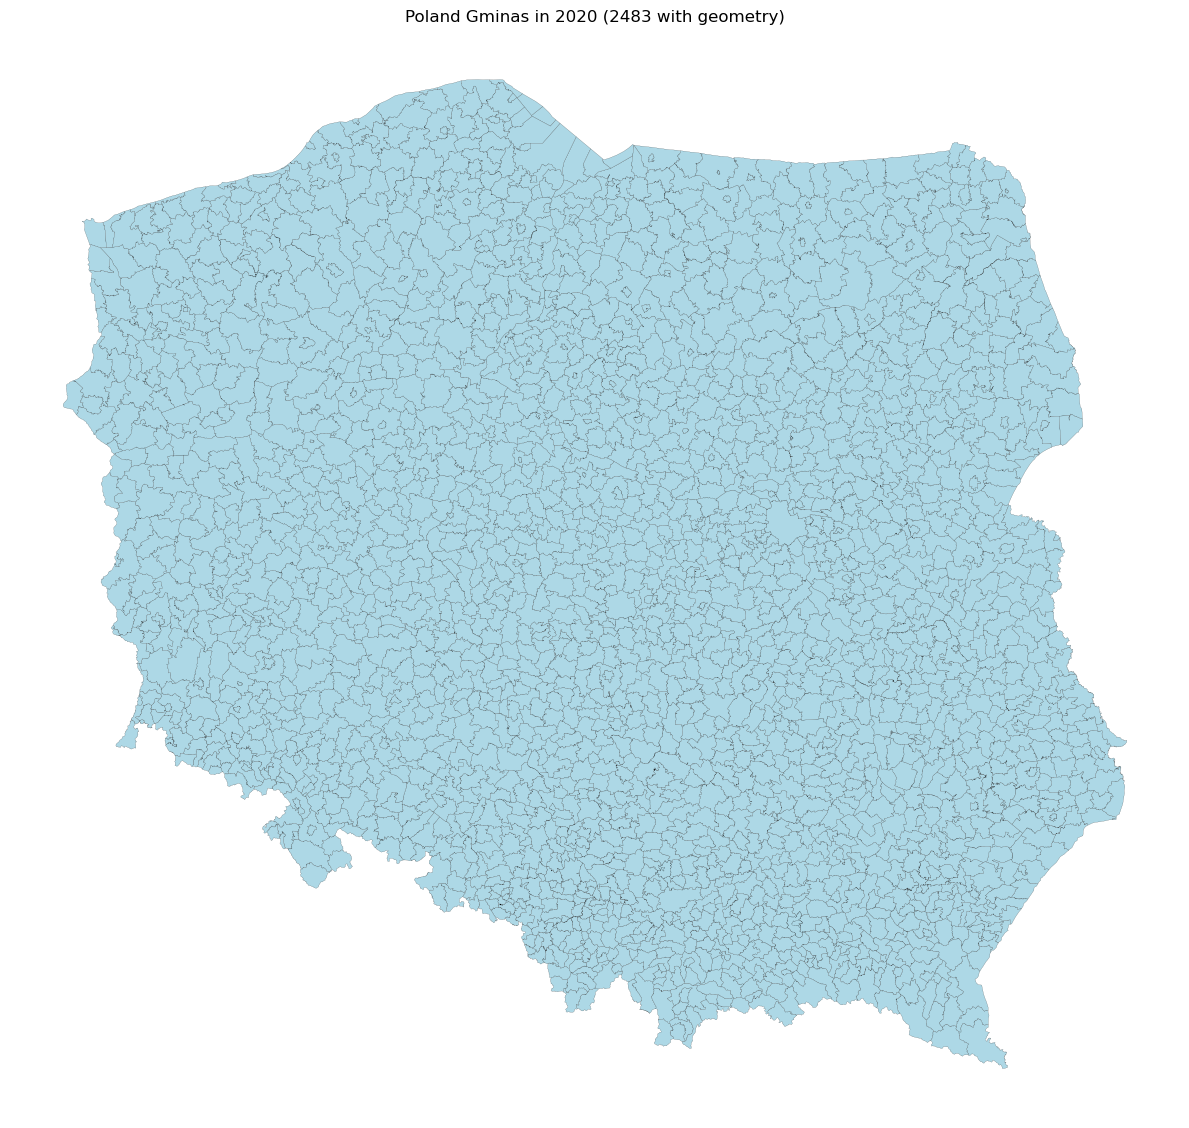

In [11]:
# Plot gminas with geometry
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
gdf_valid = gdf_2020[gdf_2020.geometry.notna()]
gdf_valid.plot(ax=ax, edgecolor='black', linewidth=0.1, facecolor='lightblue')
ax.set_title(f'Poland Gminas in 2020 ({len(gdf_valid)} with geometry)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Voivodeships (merged): 16


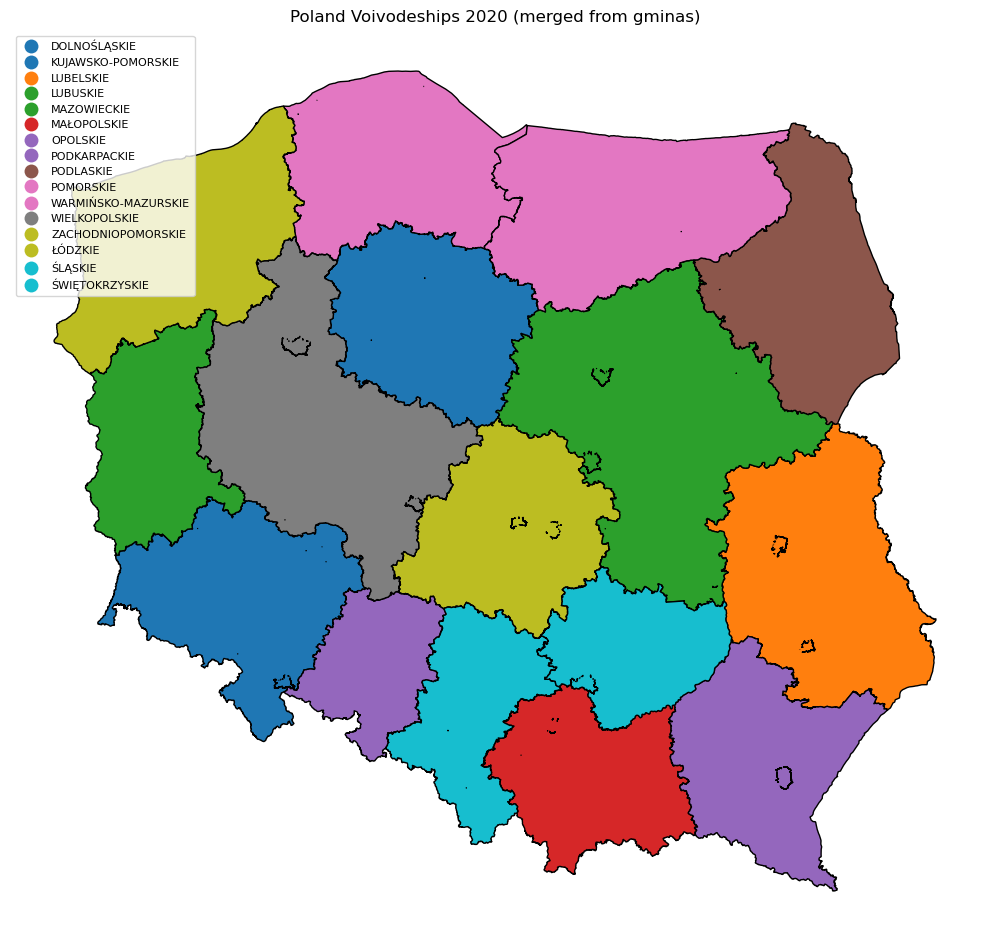

In [12]:
# Merge to voivodeship level
voivodeships_2020 = db.merge_to_level(year=2020, target_level=2)

print(f"Voivodeships (merged): {len(voivodeships_2020)}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
voivodeships_2020.plot(ax=ax, edgecolor='black', linewidth=1, 
                        column='name', legend=True, legend_kwds={'loc': 'upper left', 'fontsize': 8})
ax.set_title('Poland Voivodeships 2020 (merged from gminas)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

Powiats (merged): 380


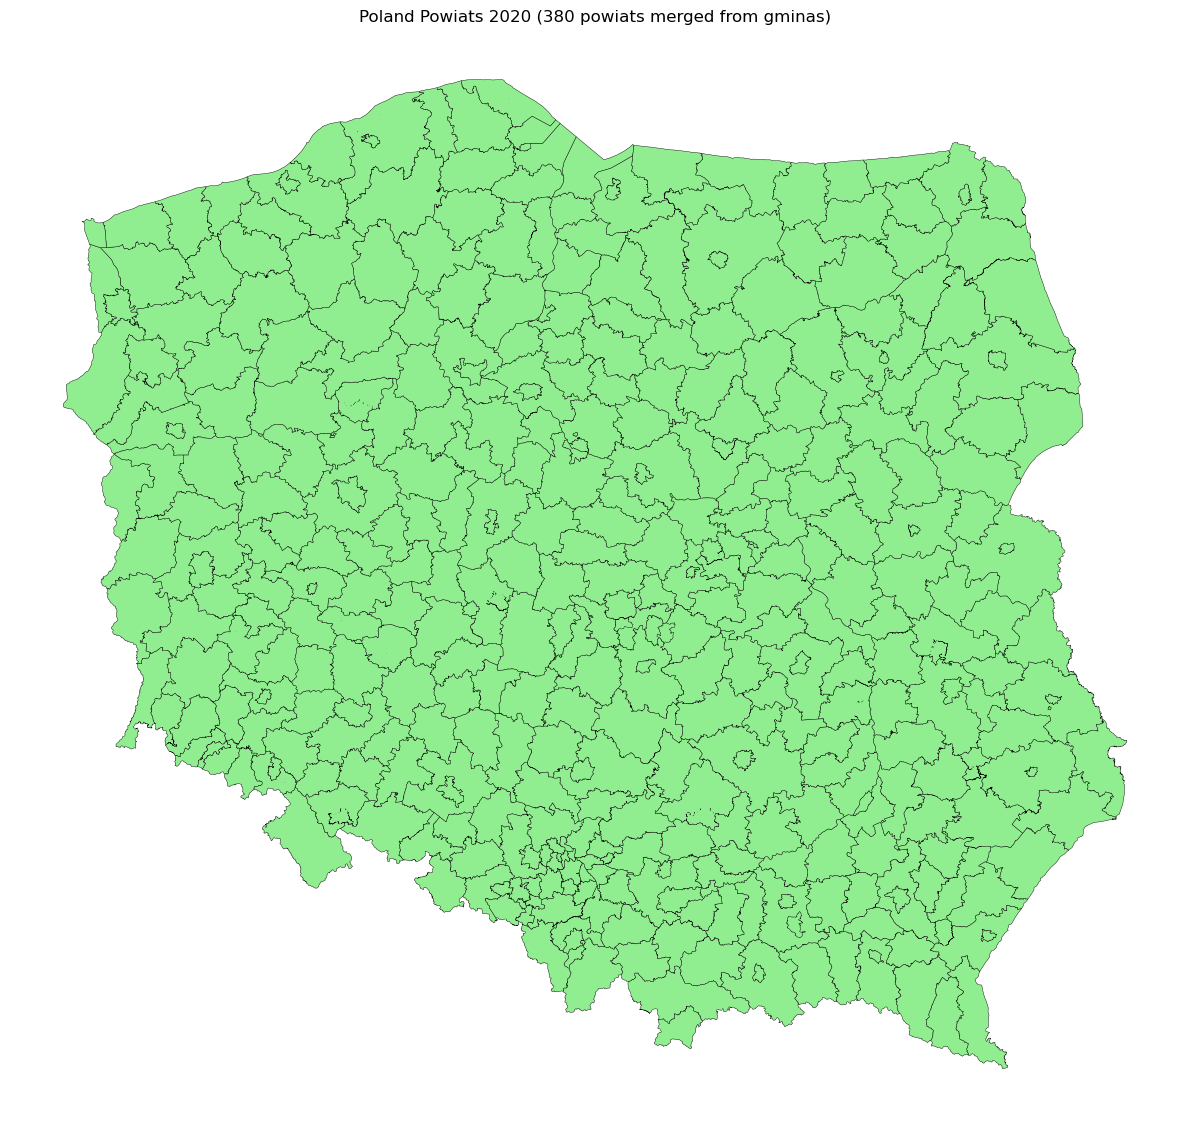

In [13]:
# Merge to powiat level
powiats_2020 = db.merge_to_level(year=2020, target_level=5)

print(f"Powiats (merged): {len(powiats_2020)}")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
powiats_2020.plot(ax=ax, edgecolor='black', linewidth=0.3, facecolor='lightgreen')
ax.set_title(f'Poland Powiats 2020 ({len(powiats_2020)} powiats merged from gminas)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. Compare Years

In [14]:
# Compare gmina counts across years
years_to_compare = [1999, 2005, 2010, 2015, 2020, 2024]
counts = []

for year in years_to_compare:
    stats = db.get_year_statistics(year)
    gminas = stats['level_counts'].get(6, 0)
    powiats = stats['level_counts'].get(5, 0)
    voivodeships = stats['level_counts'].get(2, 0)
    counts.append({
        'year': year,
        'gminas': gminas,
        'powiats': powiats,
        'voivodeships': voivodeships
    })

counts_df = pd.DataFrame(counts)
print(counts_df.to_string(index=False))

 year  gminas  powiats  voivodeships
 1999    3649      373            16
 2005    3675      379            16
 2010    3710      379            16
 2015    3737      380            16
 2020    3800      380            16
 2024    3938      380            16


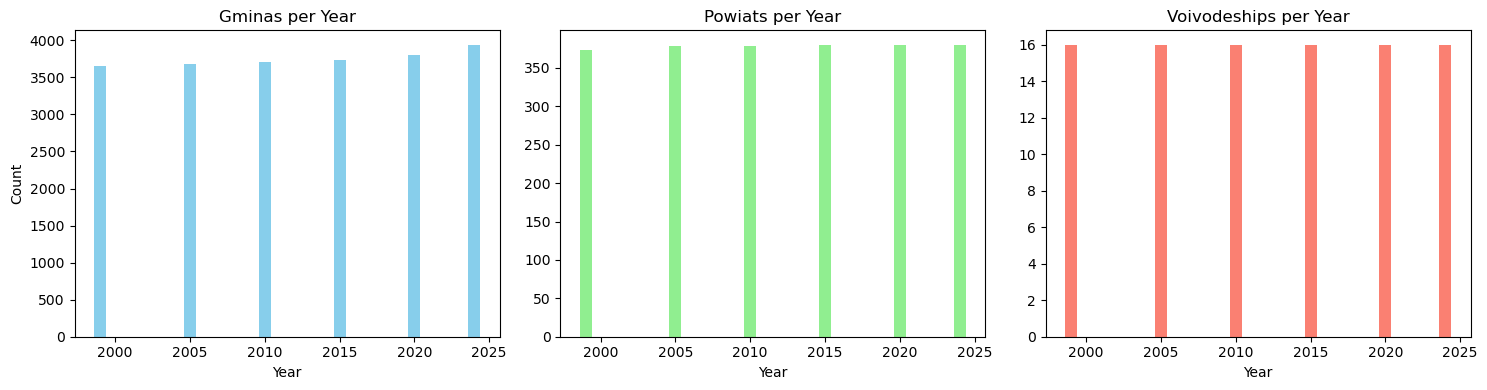

In [15]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(counts_df['year'], counts_df['gminas'], color='skyblue')
axes[0].set_title('Gminas per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

axes[1].bar(counts_df['year'], counts_df['powiats'], color='lightgreen')
axes[1].set_title('Powiats per Year')
axes[1].set_xlabel('Year')

axes[2].bar(counts_df['year'], counts_df['voivodeships'], color='salmon')
axes[2].set_title('Voivodeships per Year')
axes[2].set_xlabel('Year')

plt.tight_layout()
plt.show()

## 7. Export Database

In [16]:
# Export to DataFrame
db_df = db.to_dataframe(include_geometry=False)
print(f"Exported {len(db_df)} records to DataFrame")
db_df

Exported 4560 records to DataFrame


,teryt_id,name,name_dod,level,kind,woj,pow,gmi,rodz,years_valid,...,past_kinds,all_teryt_ids,all_names,changes,has_changes,n_changes,has_geometry,geometry_year,old_woj,old_woj_id
0,0200000,DOLNOŚLĄSKIE,województwo,2,NaN,02,00,00,0,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[0200000],[DOLNOŚLĄSKIE],[],False,0,False,NaN,None,None
1,0201000,bolesławiecki,powiat,5,NaN,02,01,00,0,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[0201000],[bolesławiecki],[],False,0,False,NaN,None,None
2,0201011,Bolesławiec,gmina miejska,6,urban,02,01,01,1,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[0201011],[Bolesławiec],[],False,0,True,2023.0,None,None
3,0201022,Bolesławiec,gmina wiejska,6,rural,02,01,02,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[0201022],[Bolesławiec],[],False,0,True,2023.0,None,None
4,0201032,Gromadka,gmina wiejska,6,rural,02,01,03,2,"[1999, 2000, 2001, 2002, 2003, 2004, 2005, 200...",...,[],[0201032],[Gromadka],[],False,0,True,2023.0,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,2612015,Bogoria,obszar wiejski,6,village,26,12,01,5,[2024],...,[],[2612015],[Bogoria],"[{'year': 2024, 'type': 'reform', 'description...",True,1,False,NaN,None,None
4556,3008064,Rychtal,miasto,6,town,30,08,06,4,[2024],...,[],[3008064],[Rychtal],"[{'year': 2024, 'type': 'reform', 'description...",True,1,False,NaN,None,None
4557,3008065,Rychtal,obszar wiejski,6,village,30,08,06,5,[2024],...,[],[3008065],[Rychtal],"[{'year': 2024, 'type': 'reform', 'description...",True,1,False,NaN,None,None
4558,3028044,Mieścisko,miasto,6,town,30,28,04,4,[2024],...,[],[3028044],[Mieścisko],"[{'year': 2024, 'type': 'reform', 'description...",True,1,False,NaN,None,None


In [17]:
# Save to CSV
output_path = geospatial_root / "geoteryt_database.csv"
db_df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Saved to {output_path}")

Saved to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_database.csv


In [18]:
# Export specific year to GeoPackage (if geopandas supports it)
try:
    output_gpkg = geospatial_root / "gminas_2020.gpkg"
    db.export_to_geopackage(output_gpkg, year=2020, level=6)
    print(f"Exported 2020 gminas to {output_gpkg}")
except Exception as e:
    print(f"GeoPackage export not available: {e}")

Exported 2020 gminas to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/gminas_2020.gpkg


## 8. Save Complete Database

Save the complete database with all geometries using `save_complete()`. This creates a pickle file that can be loaded with `load_complete_database()` for instant access without rebuilding.

In [19]:
# Save the complete database (with geometries) using pickle
# If db was created before module reload, attach the new methods
if not hasattr(db, 'save_complete'):
    import types
    db.save_complete = types.MethodType(gtdb.GeoTERYTDatabase.save_complete, db)
    print("ℹ Added save_complete method from reloaded module")

complete_db_path = geospatial_root / "geoteryt_complete.pkl"
db.save_complete(complete_db_path)
print(f"\n✓ Complete database saved to: {complete_db_path}")

Saving complete database to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete.pkl...
  ✓ Saved 4560 records
  ✓ File size: 1201.4 MB
  ✓ Path: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete.pkl

✓ Complete database saved to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete.pkl


## Summary

The GeoTERYT database v3.0 has been successfully built and saved. Key capabilities:

1. **Data Storage**: All administrative divisions from 1999-2024
2. **Historical Tracking**: Name changes, ID changes, structural changes (all_teryt_ids, all_names)
3. **Geometry Integration**: Multiple shapefile sources linked to records
4. **Pre-1999 Support**: old_woj, old_woj_id attributes for historical voivodeships
5. **Search**: By TERYT ID, name, year, level, kind
6. **Geometry Operations**: Merge to higher levels, best geometry selection
7. **Export**: DataFrame, CSV, GeoPackage, pickle (complete with geometries)
8. **Display**: TERYTRecord.display() for nice Jupyter output, as_df() for DataFrames

### To load the complete database elsewhere:
```python
from geoTERYT_db import load_complete_database
db = load_complete_database("path/to/geoteryt_complete.pkl")
```